# Real Quantum Hardware


The noiseless simulator confirmed that the Trotter circuit correctly implements the Z₂-Higgs Hamiltonian.  
We now run the exact same circuits on real IBM quantum hardware (ibm_kingston)

In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import json
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2, Batch
from qiskit_ibm_runtime.options import SamplerOptions

plt.rcParams.update({'font.size':11, 'figure.dpi':130, 'lines.linewidth':2})

# ── Connect to hardware ─────────────────────────────────────────
service = QiskitRuntimeService()
backend = service.backend('ibm_kingston')
print(f'Connected to: {backend.name}')
print(f'Qubits: {backend.num_qubits}')
print(f'Status: {backend.status().operational}')

Connected to: ibm_kingston
Qubits: 156
Status: True


## Setup Classical Reference Functions

We redefine here the same operators and functions from the classical simulation notebook. These are
needed to compute the exact diagonalization reference curves that appear in every comparison plot.


In [3]:
# ── Pauli matrices and operators ────────────────────────────────
I = np.eye(2, dtype=complex)
X = np.array([[0,1],[1,0]], dtype=complex)
Z = np.array([[1,0],[0,-1]], dtype=complex)

def kron(*ops):
    r = ops[0]
    for op in ops[1:]: r = np.kron(r, op)
    return r

def op7(pauli, site):
    ops = [I]*7; ops[site] = pauli; return kron(*ops)

TZ0=op7(Z,0); TX0=op7(X,0)
SZ0=op7(Z,1); SX0=op7(X,1)
TZ1=op7(Z,2); TX1=op7(X,2)
SZ1=op7(Z,3); SX1=op7(X,3)
TZ2=op7(Z,4); TX2=op7(X,4)
SZ2=op7(Z,5); SX2=op7(X,5)
TZ3=op7(Z,6); TX3=op7(X,6)

def build_H7(m, g, lam):
    return (-m*(TZ0+TZ1+TZ2+TZ3)
            -g*(SZ0+SZ1+SZ2)
            -lam*(TX0@SX0@TX1 + TX1@SX1@TX2 + TX2@SX2@TX3))

def evolve(H, psi0, times):
    evals, evecs = la.eigh(H)
    return [evecs@(np.exp(-1j*evals*t)*(evecs.conj().T@psi0))
            for t in times]

def occ(psi, TZ):
    return float(np.real((1 - psi.conj()@TZ@psi)/2))

psi0 = np.zeros(128, dtype=complex)
psi0[int('1101011',2)] = 1.0

print('Classical functions ready')

Classical functions ready


## Setup Trotter Circuit Functions

We redefine the same Trotter circuit functions from the quantum simulation notebook. The only difference
from the noiseless version is the addition of `qc.measure_all()` at the end of `build_trotter_circuit`, real hardware requires explicit measurement gates to read out the qubit states, whereas the noiseless simulator extracts expectation values directly from the statevector without measuring.

In [5]:
# ── Trotter circuit functions ───────────────────────────────────
def u1_half(qc, m, g, dt):
    for q in [0,2,4,6]: qc.rz(-m*dt, q)
    for q in [1,3,5]:   qc.rz(-g*dt, q)

def u1_full(qc, m, g, dt):
    for q in [0,2,4,6]: qc.rz(-2*m*dt, q)
    for q in [1,3,5]:   qc.rz(-2*g*dt, q)

def pauli_gadget_xxx(qc, ql, qs, qr, lam, dt):
    qc.h(ql); qc.h(qs); qc.h(qr)
    qc.cx(ql, qs); qc.cx(qr, qs)
    qc.rz(-2*lam*dt, qs)
    qc.cx(qr, qs); qc.cx(ql, qs)
    qc.h(ql); qc.h(qs); qc.h(qr)

def u3(qc, lam, dt):
    pauli_gadget_xxx(qc, 0, 1, 2, lam, dt)
    pauli_gadget_xxx(qc, 2, 3, 4, lam, dt)
    pauli_gadget_xxx(qc, 4, 5, 6, lam, dt)

def build_trotter_circuit(m, g, lam, dt, L):
    qc = QuantumCircuit(7)
    for q in [0,1,3,5,6]: qc.x(q)
    u1_half(qc, m, g, dt)
    for _ in range(L-1):
        u3(qc, lam, dt)
        u1_full(qc, m, g, dt)
    u3(qc, lam, dt)
    u1_half(qc, m, g, dt)
    qc.measure_all()   # add measurements for hardware
    return qc

print('Trotter functions ready')

Trotter functions ready


## Hardware Calibration and Simulation Parameters

Before submitting any circuits we check the daily calibration data of ibm_kingston. T1 and T2 tell us how long qubits maintain their state and phase
coherence respectively the longer the better.

We also define the simulation parameters used throughout all hardware runs:
- **dt = 0.15** : optimal Trotter step from error analysis
- **20 time points** from t=0 to t=6 λ⁻¹
- **Confined phase:** m=5, g=2, λ=1
- **Breaking regime:** m=0.5, g=1.5, λ=1

We limit the simulation to t=6 λ⁻¹ on hardware (instead of t=10 on the noiseless simulator) to
keep the maximum circuit depth at L=40 layers a reasonable depth given the hardware noise level.

In [9]:
# ── Check calibration ───────────────────────────────────────────
props = backend.properties()

t1_values = []
t2_values = []
for q in range(backend.num_qubits):
    try:
        t1_values.append(props.t1(q) * 1e6)
    except:
        pass
    try:
        t2_values.append(props.t2(q) * 1e6)
    except:
        pass

print(f'Qubits with T1 data: {len(t1_values)} out of {backend.num_qubits}')
print(f'Median T1: {np.median(t1_values):.1f} µs')
print(f'Median T2: {np.median(t2_values):.1f} µs')

# Define simulation parameters
dt_opt   = 0.15
times_hw = np.linspace(0, 6, 20)
m_conf, g_conf, lam_conf = 5.0, 2.0, 1.0
m_brk,  g_brk,  lam_brk  = 0.5, 1.5, 1.0

print(f'\nTime points: {len(times_hw)}')
print(f'dt = {dt_opt}')
print(f'Max layers L = {max(1, round(6/dt_opt))}')

Qubits with T1 data: 155 out of 156
Median T1: 231.0 µs
Median T2: 135.7 µs

Time points: 20
dt = 0.15
Max layers L = 40


In [57]:
for gate in props.gates:
    if gate.gate == 'cz':
        for param in gate.parameters:
            if param.name == 'gate_length':
                print(f'CZ {gate.qubits}: raw value = {param.value}ns')

        break

for gate in props.gates:
    if gate.gate == 'sx' and gate.qubits == [0]:
        for param in gate.parameters:
            if param.name == 'gate_length':
                print(f'SX qubit 0: raw value = {param.value}ns')
        break

CZ [72, 73]: raw value = 68ns
SX qubit 0: raw value = 32ns


In [49]:
cz_time_ns = 68    # ns
sx_time_ns = 32    # ns

# Per Trotter layer:
# - 6 CZ gates (3 gadgets × 2 CNOTs each)
# - ~8 SX gates (from transpilation of H gates)
# - Rz gates: virtual, zero time

time_per_layer_ns = 6 * cz_time_ns + 8 * sx_time_ns
print(f'Time per Trotter layer: {time_per_layer_ns} ns')

# For different simulation times
for t, L in [(0.3,2), (3.0,20), (6.0,40)]:
    total_ns = L * time_per_layer_ns
    print(f't={t} λ⁻¹ (L={L} layers): {total_ns} ns = {total_ns/1000:.1f} µs')

Time per Trotter layer: 664 ns
t=0.3 λ⁻¹ (L=2 layers): 1328 ns = 1.3 µs
t=3.0 λ⁻¹ (L=20 layers): 13280 ns = 13.3 µs
t=6.0 λ⁻¹ (L=40 layers): 26560 ns = 26.6 µs


## Calibration Results

ibm_kingston reports calibration data for 155 out of 156 qubits one qubit has no available data and is automatically excluded by the compiler.

- **T1 = 231.0 µs** — qubits maintain their excited state for 231 µs before relaxing to |0⟩
- **T2 = 135.7 µs** — qubits maintain phase coherence for 135.7 µs before dephasing

**Actual gate times on ibm_kingston:**
- CZ gate: **68 ns**
- SX gate: **32 ns**
- Rz gate: **0 ns** (virtual gate, no time cost)

**Circuit execution times:**

Each Trotter layer takes:
6 CZ × 68 ns + 8 SX × 32 ns = 408 + 256 = **664 ns**

| Time point | Layers L | Circuit duration |
|-----------|---------|-----------------|
| t=0.3 λ⁻¹ | L=2 | 1.3 µs |
| t=3.0 λ⁻¹ | L=20 | 13.3 µs |
| t=6.0 λ⁻¹ | L=40 | 26.6 µs |

All circuit durations are well within T1=231 µs and T2=135.7 µs meaning the hardware can execute our circuits before decoherence destroys the signal
completely.

**Simulation setup:**
- 20 time points from t=0 to t=6 λ⁻¹
- dt=0.15 → L = round(t/dt) layers per circuit (ranges from L=1 at short times to L=40 at t=6)
- 40 total circuits per hardware run (20 confined + 20 breaking)

---

## Step 1: Building and Transpiling Circuits

We build one Trotter circuit per time point for each parameter set:

- **Confined phase** (m=5, g=2, λ=1): 20 circuits
- **Breaking regime** (m=0.5, g=1.5, λ=1): 20 circuits
- **Total: 40 circuits**

At t=0 we only apply X gates to prepare the initial state and measure immediately no Trotter layers needed. For t > 0 the number of layers is L = round(t/dt) with dt=0.15.

**Transpilation** converts our abstract circuit into the native gate set of ibm_kingston (CZ, SX, Rz)
and maps our 7 virtual qubits to 7 physical qubits on the chip. We use optimization level 3 the
highest level which lets Qiskit choose the best qubit layout and minimize the circuit depth.

In [11]:
#def build_all_circuits(m, g, lam, times, dt):
    """Build and transpile Trotter circuits for all time points."""
    circuits = []
    for t in times:
        if t == 0:
            # Just state preparation + measurement
            qc = QuantumCircuit(7)
            for q in [0,1,3,5,6]: qc.x(q)
            qc.measure_all()
        else:
            L  = max(1, round(t/dt))
            qc = build_trotter_circuit(m, g, lam, t/L, L)
        circuits.append(qc)
    return circuits

# Build circuits for confined phase
print('Building confined phase circuits...')
circs_conf = build_all_circuits(m_conf, g_conf, lam_conf,
                                 times_hw, dt_opt)

# Build circuits for breaking regime
print('Building breaking regime circuits...')
circs_brk  = build_all_circuits(m_brk, g_brk, lam_brk,
                                 times_hw, dt_opt)

all_circuits = circs_conf + circs_brk
print(f'Total circuits: {len(all_circuits)}')

# Transpile for ibm_kingston
print('Transpiling...')
transpiled = transpile(all_circuits,
                       backend=backend,
                       optimization_level=3)
print(f'Transpilation complete')
print(f'Example circuit depth: {transpiled[10].depth()}')
print(f'Example CNOT count: {transpiled[10].count_ops().get("cx",0)}')

Building confined phase circuits...
Building breaking regime circuits...
Total circuits: 40
Transpiling...
Transpilation complete
Example circuit depth: 485
Example CNOT count: 0


#### Circuits Built and Transpiled

40 circuits successfully built and transpiled for
ibm_kingston:
- 20 circuits for the confined phase
- 20 circuits for the breaking regime

Qiskit's compiler mapped our 7 virtual qubits to 7 physical qubits on the chip and converted all gates to the native ibm_kingston gate set (CZ, SX,
Rz). We inspect the gate counts in the next cell to verify the transpilation is correct and estimate
the expected noise level.

In [13]:
# Check native gate counts
ops = transpiled[10].count_ops()
print('Gate counts for example circuit (t≈3):')
for gate, count in sorted(ops.items()):
    print(f'  {gate}: {count}')

print(f'\nCircuit depth: {transpiled[10].depth()}')

# Check a shallow circuit (t≈0.3, L=2)
ops_shallow = transpiled[1].count_ops()
print('\nShallow circuit (t≈0.3):')
for gate, count in sorted(ops_shallow.items()):
    print(f'  {gate}: {count}')
print(f'Depth: {transpiled[1].depth()}')

Gate counts for example circuit (t≈3):
  barrier: 1
  cz: 252
  measure: 7
  rz: 380
  sx: 336
  x: 124

Circuit depth: 485

Shallow circuit (t≈0.3):
  barrier: 1
  cz: 24
  measure: 7
  rz: 40
  sx: 32
  x: 10
Depth: 48


## Gate Count Results

| | Shallow (t≈0.3, L=2) | Deep (t≈3, L=20) |
|--|---------------------|-----------------|
| CZ gates | 24 | 252 |
| SX gates | 32 | 336 |
| Rz gates | 40 | 380 |
| X gates | 10 | 124 |
| Circuit depth | 48 | 485 |

**Key observations:**

- CNOT count = 0 in both circuits confirms all our CNOT gates were correctly converted to the native CZ gate during transpilation
- CZ count scales with depth: shallow has 24, deep has 252 roughly 10× more, consistent with 10× more Trotter layers
---

#### Step 2: Raw Hardware Run: No Error Mitigation

We submit all 40 transpiled circuits to ibm_kingston using IBM's SamplerV2 primitive in Batch mode.
Batch mode groups all circuits into one session reducing queue wait time and ensuring all circuits
run under the same hardware conditions (same calibration, same qubit layout, same temperature).

We use **10000 shots per circuit** giving a statistical uncertainty

Results are saved immediately to `raw_hardware_results.json` after the job completes.

**No error mitigation is applied here.**

In [19]:
SHOTS = 10000

print(f'Submitting {len(transpiled)} circuits to {backend.name}')
print(f'Shots per circuit: {SHOTS}')
print(f'Estimated total shots: {len(transpiled) * SHOTS:,}')
print('Submitting...')

with Batch(backend=backend) as batch:
    sampler = SamplerV2(mode=batch)
    job_raw = sampler.run(transpiled, shots=SHOTS)

print(f'Job submitted successfully')
print(f'Job ID: {job_raw.job_id()}')
print('Waiting for results...')

result_raw = job_raw.result()
print('Done!')

# Save immediately
raw_data = []
for pub_result in result_raw:
    counts = pub_result.data.meas.get_counts()
    raw_data.append(counts)

with open('raw_hardware_results.json', 'w') as f:
    json.dump(raw_data, f)

print(f'Results saved to raw_hardware_results.json')
print(f'Number of result sets: {len(raw_data)}')
print(f'Example counts at t=0: {list(raw_data[0].items())[:5]}')

Submitting 40 circuits to ibm_kingston
Shots per circuit: 10000
Estimated total shots: 400,000
Submitting...
Job submitted successfully
Job ID: d9urmigb1g9c73a7qd90
Waiting for results...
Done!
Results saved to raw_hardware_results.json
Number of result sets: 40
Example counts at t=0: [('1101011', 9583), ('1100011', 96), ('1101010', 46), ('1101001', 56), ('1001011', 89)]


## Raw Hardware Results Received

- **40 result sets** saved successfully

**Example counts at t=0 (initial state |1101011⟩):**

At t=0 with no circuit evolution, **95.8% of shots correctly measured |1101011⟩**. The remaining 4.2%
are readout errors the state was correct but the measurement registered the wrong bit.

In [17]:
#only for reload data from my hardware whrn the notebook disconnects
import json

# Load raw hardware results
with open('raw_hardware_results.json', 'r') as f:
    raw_data = json.load(f)

# Load Pauli twirling results
with open('pt_hardware_results.json', 'r') as f:
    pt_data = json.load(f)

print(f'Raw results loaded: {len(raw_data)} circuits')
print(f'PT results loaded:  {len(pt_data)} circuits')

# Split into confined and breaking
n = 20   # number of time points
raw_conf = raw_data[:n];  raw_brk = raw_data[n:]
pt_conf  = pt_data[:n];   pt_brk  = pt_data[n:]

# Process into expectation values
occ_raw_conf = {
    'tau0': [counts_to_occupation(c, 0) for c in raw_conf],
    'tau1': [counts_to_occupation(c, 2) for c in raw_conf],
    'tau2': [counts_to_occupation(c, 4) for c in raw_conf],
    'tau3': [counts_to_occupation(c, 6) for c in raw_conf],
    'sz0':  [counts_to_flux(c, 1) for c in raw_conf],
    'sz1':  [counts_to_flux(c, 3) for c in raw_conf],
    'sz2':  [counts_to_flux(c, 5) for c in raw_conf],
}
occ_raw_brk = {
    'tau0': [counts_to_occupation(c, 0) for c in raw_brk],
    'tau1': [counts_to_occupation(c, 2) for c in raw_brk],
    'tau2': [counts_to_occupation(c, 4) for c in raw_brk],
    'tau3': [counts_to_occupation(c, 6) for c in raw_brk],
    'sz0':  [counts_to_flux(c, 1) for c in raw_brk],
    'sz1':  [counts_to_flux(c, 3) for c in raw_brk],
    'sz2':  [counts_to_flux(c, 5) for c in raw_brk],
}
occ_pt_conf = {
    'tau0': [counts_to_occupation(c, 0) for c in pt_conf],
    'tau1': [counts_to_occupation(c, 2) for c in pt_conf],
    'tau2': [counts_to_occupation(c, 4) for c in pt_conf],
    'tau3': [counts_to_occupation(c, 6) for c in pt_conf],
    'sz0':  [counts_to_flux(c, 1) for c in pt_conf],
    'sz1':  [counts_to_flux(c, 3) for c in pt_conf],
    'sz2':  [counts_to_flux(c, 5) for c in pt_conf],
}
occ_pt_brk = {
    'tau0': [counts_to_occupation(c, 0) for c in pt_brk],
    'tau1': [counts_to_occupation(c, 2) for c in pt_brk],
    'tau2': [counts_to_occupation(c, 4) for c in pt_brk],
    'tau3': [counts_to_occupation(c, 6) for c in pt_brk],
    'sz0':  [counts_to_flux(c, 1) for c in pt_brk],
    'sz1':  [counts_to_flux(c, 3) for c in pt_brk],
    'sz2':  [counts_to_flux(c, 5) for c in pt_brk],
}

print('All hardware results loaded and processed')
print(f'Raw  τ₀ at t=0: {occ_raw_conf["tau0"][0]:.4f}')
print(f'PT   τ₀ at t=0: {occ_pt_conf["tau0"][0]:.4f}')

Raw results loaded: 40 circuits
PT results loaded:  40 circuits
All hardware results loaded and processed
Raw  τ₀ at t=0: 0.9952
PT   τ₀ at t=0: 0.9947


## Step 3: Processing Raw Results

The hardware returns measurement counts — dictionaries mapping bitstrings to the number
of times each was observed. We convert these into physical expectation values.

**From counts to expectation values:**

For each qubit we compute ⟨Z⟩ by reading the bit value from each bitstring and averaging over all shots:

$$\langle Z \rangle = \frac{1}{N}\sum_{\text{shots}} (1 - 2b_k)$$

where $b_k$ is the bit value at qubit k (0 or 1) and N is the total number of shots. The factor
(1−2b) converts: bit=0 → +1, bit=1 → −1, matching the Z eigenvalues.


From ⟨Z⟩ we extract:
- **Occupation:** (1 − ⟨Z⟩)/2 for matter qubits
- **Flux:** ⟨Z⟩ directly for gauge qubits

We split the 40 results into confined (first 20) and breaking (last 20) and extract all observables for both scenarios.

In [19]:
def counts_to_expval_Z(counts, qubit, n_qubits=7):
    """
    Compute <Z> on a specific qubit from measurement counts.
    Qiskit bitstring convention: rightmost bit = qubit 0.
    
    Parameters
    ----------
    counts  : dict of bitstring → count
    qubit   : physical qubit index (0-6)
    n_qubits: total number of qubits
    
    Returns
    -------
    expval : float between -1 and +1
    """
    total = sum(counts.values())
    expval = 0.0
    for bitstring, count in counts.items():
        # Qiskit: rightmost bit = qubit 0
        # Remove spaces if present
        bits = bitstring.replace(' ','')
        # bit at position qubit (from right)
        bit = int(bits[-(qubit+1)])
        # Z eigenvalue: 0 → +1, 1 → -1
        expval += count * (1 - 2*bit)
    return expval / total

def counts_to_occupation(counts, qubit, n_qubits=7):
    """(1 - <Z>) / 2 from counts."""
    return (1 - counts_to_expval_Z(counts, qubit, n_qubits)) / 2

def counts_to_flux(counts, qubit, n_qubits=7):
    """<Z> directly from counts."""
    return counts_to_expval_Z(counts, qubit, n_qubits)

# Process confined phase results
n = len(times_hw)
raw_conf = raw_data[:n]
raw_brk  = raw_data[n:]

# Confined: extract occupation at all matter sites
occ_raw_conf = {
    'tau0': [counts_to_occupation(c, 0) for c in raw_conf],
    'tau1': [counts_to_occupation(c, 2) for c in raw_conf],
    'tau2': [counts_to_occupation(c, 4) for c in raw_conf],
    'tau3': [counts_to_occupation(c, 6) for c in raw_conf],
    'sz0':  [counts_to_flux(c, 1) for c in raw_conf],
    'sz1':  [counts_to_flux(c, 3) for c in raw_conf],
    'sz2':  [counts_to_flux(c, 5) for c in raw_conf],
}

# Breaking: extract occupation at all matter sites
occ_raw_brk = {
    'tau0': [counts_to_occupation(c, 0) for c in raw_brk],
    'tau1': [counts_to_occupation(c, 2) for c in raw_brk],
    'tau2': [counts_to_occupation(c, 4) for c in raw_brk],
    'tau3': [counts_to_occupation(c, 6) for c in raw_brk],
    'sz0':  [counts_to_flux(c, 1) for c in raw_brk],
    'sz1':  [counts_to_flux(c, 3) for c in raw_brk],
    'sz2':  [counts_to_flux(c, 5) for c in raw_brk],
}

print('Raw results processed successfully')
print(f'Confined τ₀ at t=0: {occ_raw_conf["tau0"][0]:.4f} (expected 1.0)')
print(f'Confined τ₁ at t=0: {occ_raw_conf["tau1"][0]:.4f} (expected 0.0)')
print(f'Confined σ₁ at t=0: {occ_raw_conf["sz1"][0]:.4f}  (expected -1.0)')

Raw results processed successfully
Confined τ₀ at t=0: 0.9952 (expected 1.0)
Confined τ₁ at t=0: 0.0016 (expected 0.0)
Confined σ₁ at t=0: -0.9800  (expected -1.0)


All three values are very close to their expected values at t=0 confirming the initial state preparation is correct on the real hardware.

---

## Computing Reference Curves

Before plotting the hardware results we compute two reference curves that appear in every plot:

**Exact diagonalization:**
We compute the perfect classical solution for both scenarios using 300 time points for smooth
curves. This is the ground truth the correct answer the hardware should reproduce.

**Noiseless simulator:**
We run the same Trotter circuit on the noiseless Qiskit statevector simulator at the same 20 time points used in the hardware run. This shows what the circuit produces without any hardware noise the gap between noiseless and exact is the Trotter error, the gap between noiseless and raw hardware is the noise.


In [74]:
# ── Exact diagonalization reference ────────────────────────────
times_exact = np.linspace(0, 6, 300)

H_conf  = build_H7(m_conf, g_conf, lam_conf)
st_conf = evolve(H_conf, psi0, times_exact)

H_brk   = build_H7(m_brk, g_brk, lam_brk)
st_brk  = evolve(H_brk, psi0, times_exact)

# ── Noiseless Trotter reference ─────────────────────────────────
from qiskit.quantum_info import Statevector, SparsePauliOp

def get_noiseless(m, g, lam, times, qubit, dt=0.15):
    results = []
    for t in times:
        if t == 0:
            results.append(1.0 if qubit in [0,6] else 0.0)
            continue
        L = max(1, round(t/dt))
        qc_nl = QuantumCircuit(7)
        for q in [0,1,3,5,6]: qc_nl.x(q)
        u1_half(qc_nl, m, g, t/L)
        for _ in range(L-1):
            u3(qc_nl, lam, t/L)
            u1_full(qc_nl, m, g, t/L)
        u3(qc_nl, lam, t/L)
        u1_half(qc_nl, m, g, t/L)
        sv  = Statevector.from_instruction(qc_nl)
        ps  = 'I'*(6-qubit) + 'Z' + 'I'*qubit
        expZ = float(np.real(sv.expectation_value(SparsePauliOp(ps))))
        results.append((1-expZ)/2)
    return results

def get_noiseless_flux(m, g, lam, times, qubit, dt=0.15):
    results = []
    for t in times:
        if t == 0:
            results.append(-1.0)
            continue
        L = max(1, round(t/dt))
        qc_nl = QuantumCircuit(7)
        for q in [0,1,3,5,6]: qc_nl.x(q)
        u1_half(qc_nl, m, g, t/L)
        for _ in range(L-1):
            u3(qc_nl, lam, t/L)
            u1_full(qc_nl, m, g, t/L)
        u3(qc_nl, lam, t/L)
        u1_half(qc_nl, m, g, t/L)
        sv  = Statevector.from_instruction(qc_nl)
        ps  = 'I'*(6-qubit) + 'Z' + 'I'*qubit
        return float(np.real(sv.expectation_value(SparsePauliOp(ps))))
    return results

# Precompute noiseless Trotter for all sites
nl_conf = {
    'tau0': get_noiseless(m_conf,g_conf,lam_conf, times_hw, 0),
    'tau1': get_noiseless(m_conf,g_conf,lam_conf, times_hw, 2),
    'tau2': get_noiseless(m_conf,g_conf,lam_conf, times_hw, 4),
    'tau3': get_noiseless(m_conf,g_conf,lam_conf, times_hw, 6),
}
nl_brk = {
    'tau0': get_noiseless(m_brk,g_brk,lam_brk, times_hw, 0),
    'tau1': get_noiseless(m_brk,g_brk,lam_brk, times_hw, 2),
    'tau2': get_noiseless(m_brk,g_brk,lam_brk, times_hw, 4),
    'tau3': get_noiseless(m_brk,g_brk,lam_brk, times_hw, 6),
}

## Plot: Confined Phase: Raw Hardware

We plot the occupation at all four matter sites for the confined phase comparing three curves:

- **Black solid line:** exact diagonalization
- **Hollow markers:** noiseless simulator
- **Solid markers:** raw hardware (no mitigation)

The yo-yo period Ty = 2π/(2g) = 1.57 λ⁻¹ is marked with vertical dashed lines on τ₀.

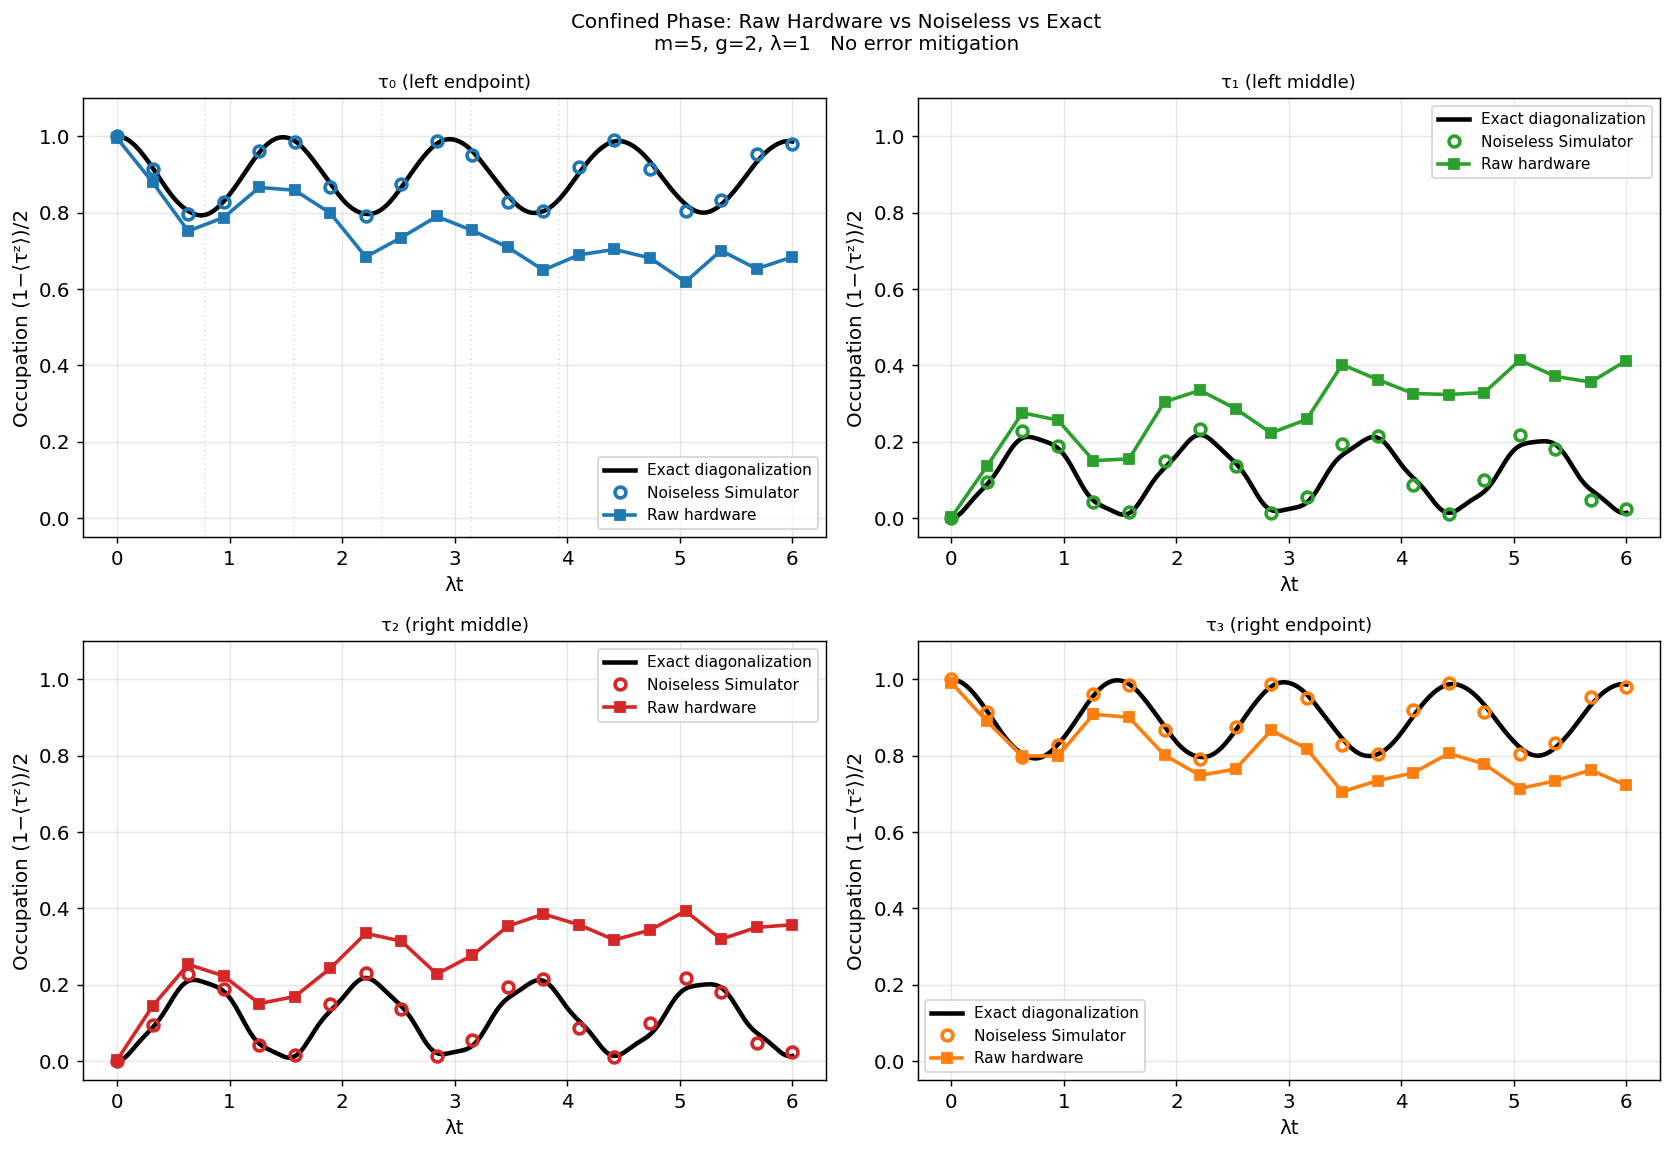

In [82]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

matter_sites = [
    (0, 'τ₀ (left endpoint)',   'C0', TZ0, 'tau0'),
    (2, 'τ₁ (left middle)',     'C2', TZ1, 'tau1'),
    (4, 'τ₂ (right middle)',    'C3', TZ2, 'tau2'),
    (6, 'τ₃ (right endpoint)',  'C1', TZ3, 'tau3'),
]

for ax, (qidx, name, col, TZ_op, key) in zip(axes, matter_sites):

    # Exact diagonalization
    ax.plot(times_exact,
            [occ(s, TZ_op) for s in st_conf],
            'k-', lw=2.5, label='Exact diagonalization')

    # Noiseless Trotter
    ax.plot(times_hw, nl_conf[key],
            'o', color=col, ms=6, mew=2,
            markerfacecolor='none', label='Noiseless Simulator')

    # Raw hardware
    ax.plot(times_hw, occ_raw_conf[key],
            color=col, lw=2, ls='-',
            marker='s', ms=5, label='Raw hardware')

    if qidx == 0:
        Ty = 2*np.pi/(2*g_conf)
        for k in range(1,6):
            ax.axvline(k*Ty/2, color='gray',
                       alpha=0.2, lw=1, ls=':')

    ax.set_xlabel('λt')
    ax.set_ylabel('Occupation (1−⟨τᶻ⟩)/2')
    ax.set_title(name, fontsize=10)
    ax.legend(fontsize=8.5)
    ax.grid(alpha=0.3)
    ax.set_ylim(-0.05, 1.1)

fig.suptitle('Confined Phase: Raw Hardware vs Noiseless vs Exact\n'
             'm=5, g=2, λ=1   No error mitigation',
             fontsize=11)
plt.tight_layout()
plt.show()


## Plot: String Breaking: Raw Hardware

We measure the flux on the middle gauge link ⟨σᶻ₁⟩ the most direct indicator of string
breaking for two parameter sets:

- **Left: Confined ΔE=+16**: control case, no breaking expected, ⟨σᶻ₁⟩ should stay at −1
- **Right: Breaking ΔE=−1**: breaking favorable, ⟨σᶻ₁⟩ should oscillate between −1 and +0.3

Same three curves as before:
- Black solid: exact diagonalization
- Hollow markers: noiseless simulator
- Solid markers: raw hardware

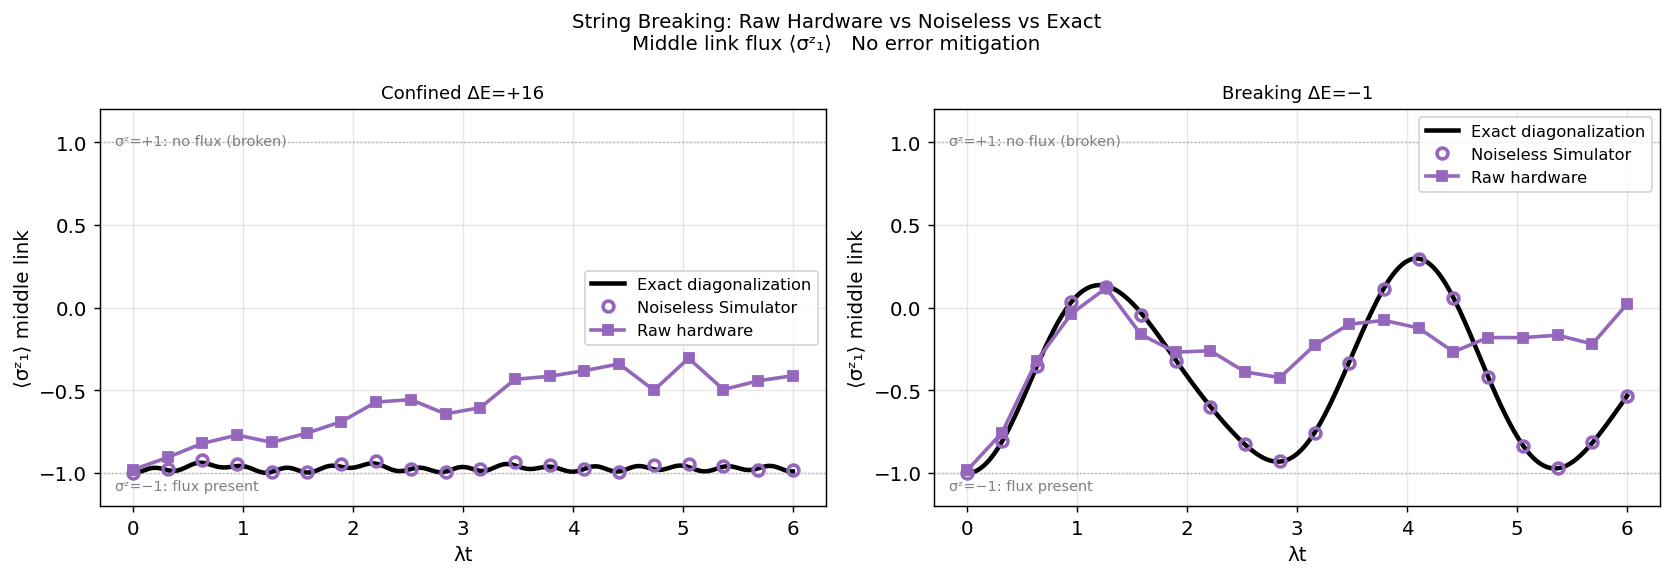

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (label, st_ex, raw_d, m, g, lam) in zip(axes, [
    ('Confined ΔE=+16',
     st_conf, occ_raw_conf, m_conf, g_conf, lam_conf),
    ('Breaking ΔE=−1',
     st_brk,  occ_raw_brk,  m_brk,  g_brk,  lam_brk),
]):
    # Exact
    ax.plot(times_exact,
            [float(np.real(s.conj()@SZ1@s)) for s in st_ex],
            'k-', lw=2.5, label='Exact diagonalization')

    # Noiseless Trotter
    sz1_nl = []
    for t in times_hw:
        if t == 0:
            sz1_nl.append(-1.0); continue
        L = max(1, round(t/0.15))
        qc_nl = QuantumCircuit(7)
        for q in [0,1,3,5,6]: qc_nl.x(q)
        u1_half(qc_nl, m, g, t/L)
        for _ in range(L-1):
            u3(qc_nl, lam, t/L)
            u1_full(qc_nl, m, g, t/L)
        u3(qc_nl, lam, t/L)
        u1_half(qc_nl, m, g, t/L)
        sv = Statevector.from_instruction(qc_nl)
        ps = 'I'*(6-3) + 'Z' + 'I'*3
        sz1_nl.append(float(np.real(
            sv.expectation_value(SparsePauliOp(ps)))))

    ax.plot(times_hw, sz1_nl,
            'o', color='C4', ms=6, mew=2,
            markerfacecolor='none', label='Noiseless Simulator')

    # Raw hardware
    ax.plot(times_hw, raw_d['sz1'],
            'C4', lw=2, ls='-', marker='s', ms=5,
            label='Raw hardware')

    ax.axhline(-1, color='gray', lw=0.8, ls=':', alpha=0.5)
    ax.axhline(+1, color='gray', lw=0.8, ls=':', alpha=0.5)
    ax.text(0.02, 0.04, 'σᶻ=−1: flux present',
            transform=ax.transAxes, fontsize=8, color='gray')
    ax.text(0.02, 0.91, 'σᶻ=+1: no flux (broken)',
            transform=ax.transAxes, fontsize=8, color='gray')

    ax.set_xlabel('λt')
    ax.set_ylabel('⟨σᶻ₁⟩ middle link')
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim(-1.2, 1.2)

fig.suptitle('String Breaking: Raw Hardware vs Noiseless vs Exact\n'
             'Middle link flux ⟨σᶻ₁⟩   No error mitigation',
             fontsize=11)
plt.tight_layout()
plt.show()


## Step 4: Pauli Twirling

Pauli twirling is an error suppression technique that converts coherent gate errors into stochastic
Pauli noise. It works by randomly inserting Pauli gates before and after each two-qubit gate in a
way that leaves the ideal unitary unchanged but randomizes the error direction across many circuit executions.


**Implementation:**
We use 32 random twirling patterns, each executed with 312 shots:
- 32 × 312 = **9984 shots total per circuit**
- Each pattern uses a different random Pauli insertion the 32 results are averaged
- Both gate twirling and measurement twirling are enabled

We submit the same 40 transpiled circuits as the raw run the only difference is the SamplerOptions enabling twirling.

Results saved to `pt_hardware_results.json`.

In [31]:
SHOTS         = 9984
NUM_RAND      = 32
SHOTS_PER_RAND = 312   # 32 × 312 = 9984 exactly

print(f'Shots: {SHOTS} ({NUM_RAND} randomizations × {SHOTS_PER_RAND} shots each)')

with Batch(backend=backend) as batch:
    options = SamplerOptions()
    options.twirling.enable_gates        = True
    options.twirling.enable_measure      = True
    options.twirling.num_randomizations  = NUM_RAND
    options.twirling.shots_per_randomization = SHOTS_PER_RAND

    sampler_pt = SamplerV2(mode=batch, options=options)
    job_pt     = sampler_pt.run(transpiled_pt, shots=SHOTS)

print(f'Job submitted')
print(f'Job ID: {job_pt.job_id()}')
print('Waiting for results...')

result_pt = job_pt.result()
print('Pauli twirling run complete!')

# Save immediately
pt_data = []
for pub_result in result_pt:
    counts = pub_result.data.meas.get_counts()
    pt_data.append(counts)

with open('pt_hardware_results.json', 'w') as f:
    json.dump(pt_data, f)

print(f'Results saved to pt_hardware_results.json')
print(f'Number of result sets: {len(pt_data)}')
print(f'Example counts at t=0: {list(pt_data[0].items())[:5]}')

Shots: 9984 (32 randomizations × 312 shots each)
Job submitted
Job ID: d9vb0m8b1g9c73a8dbg0
Waiting for results...
Pauli twirling run complete!
Results saved to pt_hardware_results.json
Number of result sets: 40
Example counts at t=0: [('1101011', 9655), ('1001011', 52), ('1100011', 51), ('1101001', 32), ('1101010', 51)]


#### Processing Pauli Twirling Results

We load the saved PT results and extract expectation values using the same processing functions as the raw hardware results.

We verify the t=0 values against the known exact values of |1101011⟩ and compare with
the raw hardware baseline to quantify the improvement from Pauli twirling.

In [33]:
# ── Process PT results ──────────────────────────────────────────
with open('pt_hardware_results.json', 'r') as f:
    pt_data = json.load(f)

pt_conf = pt_data[:n]
pt_brk  = pt_data[n:]

occ_pt_conf = {
    'tau0': [counts_to_occupation(c, 0) for c in pt_conf],
    'tau1': [counts_to_occupation(c, 2) for c in pt_conf],
    'tau2': [counts_to_occupation(c, 4) for c in pt_conf],
    'tau3': [counts_to_occupation(c, 6) for c in pt_conf],
    'sz0':  [counts_to_flux(c, 1) for c in pt_conf],
    'sz1':  [counts_to_flux(c, 3) for c in pt_conf],
    'sz2':  [counts_to_flux(c, 5) for c in pt_conf],
}

occ_pt_brk = {
    'tau0': [counts_to_occupation(c, 0) for c in pt_brk],
    'tau1': [counts_to_occupation(c, 2) for c in pt_brk],
    'tau2': [counts_to_occupation(c, 4) for c in pt_brk],
    'tau3': [counts_to_occupation(c, 6) for c in pt_brk],
    'sz0':  [counts_to_flux(c, 1) for c in pt_brk],
    'sz1':  [counts_to_flux(c, 3) for c in pt_brk],
    'sz2':  [counts_to_flux(c, 5) for c in pt_brk],
}

print('PT results processed')
print(f'Confined τ₀ at t=0: {occ_pt_conf["tau0"][0]:.4f} (expected 1.0)')
print(f'Confined σ₁ at t=0: {occ_pt_conf["sz1"][0]:.4f}  (expected -1.0)')
print(f'Breaking τ₀ at t=0: {occ_pt_brk["tau0"][0]:.4f} (expected 1.0)')

PT results processed
Confined τ₀ at t=0: 0.9947 (expected 1.0)
Confined σ₁ at t=0: -0.9894  (expected -1.0)
Breaking τ₀ at t=0: 0.9939 (expected 1.0)


## Plot: Confined Phase: Effect of Pauli Twirling

We add the Pauli twirling results to the confined
phase plot. Now four curves are shown:

- **Black solid:** exact diagonalization
- **Hollow circles:** noiseless simulator
- **Solid markers:** raw hardware
- **Hollow triangles:** hardware + Pauli twirling

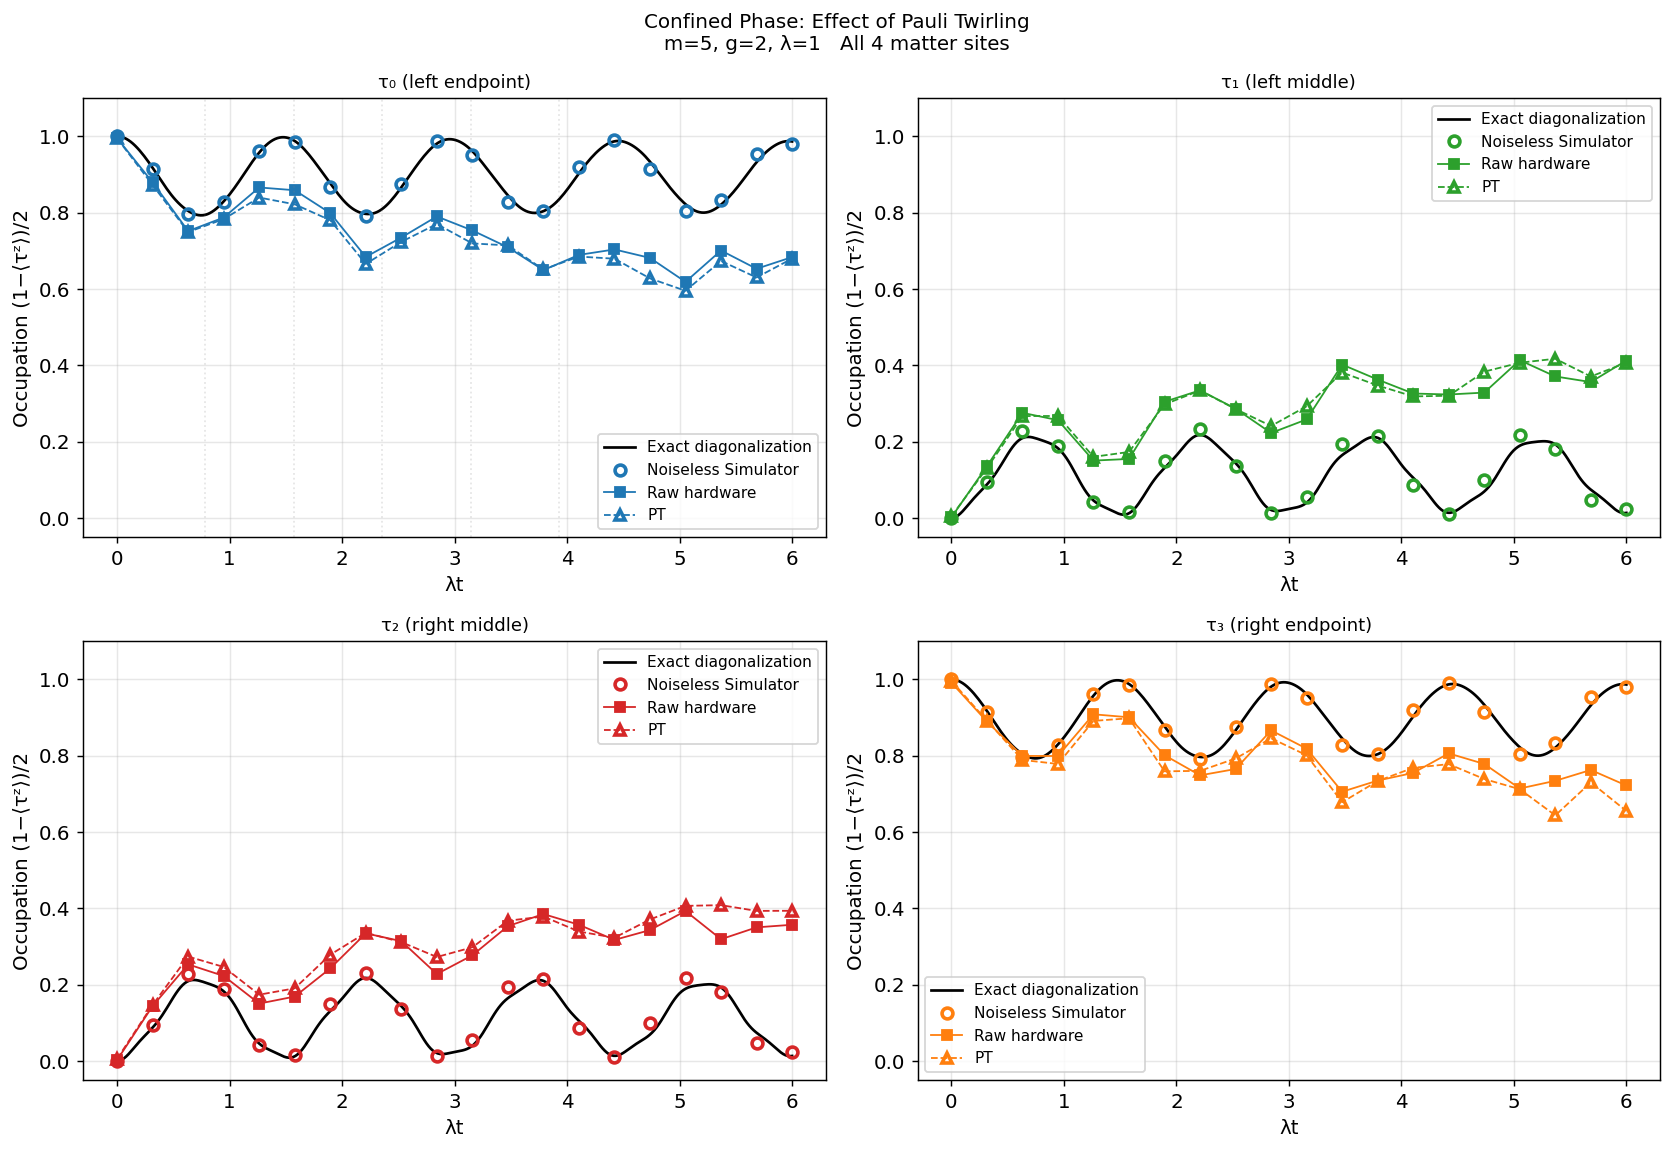

In [107]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

matter_sites = [
    (0, 'τ₀ (left endpoint)',  'C0', TZ0, 'tau0'),
    (2, 'τ₁ (left middle)',    'C2', TZ1, 'tau1'),
    (4, 'τ₂ (right middle)',   'C3', TZ2, 'tau2'),
    (6, 'τ₃ (right endpoint)', 'C1', TZ3, 'tau3'),
]

for ax, (qidx, name, col, TZ_op, key) in zip(axes, matter_sites):

    # Exact diagonalization
    ax.plot(times_exact,
            [occ(s, TZ_op) for s in st_conf],
            'k-', lw=1.5, label='Exact diagonalization')

    # Noiseless Trotter
    ax.plot(times_hw, nl_conf[key],
            'o', color=col, ms=6, mew=2,
            markerfacecolor='none', label='Noiseless Simulator')

    # Raw hardware
    ax.plot(times_hw, occ_raw_conf[key],
            color=col, lw=1, ls='-',
            marker='s', ms=5, label='Raw hardware')

    # Pauli twirling
    ax.plot(times_hw, occ_pt_conf[key],
            color=col, lw=1, ls='--',
            marker='^', ms=6, mew=2,
            markerfacecolor='none',
            label='PT')

    if qidx == 0:
        Ty = 2*np.pi/(2*g_conf)
        for k in range(1, 6):
            ax.axvline(k*Ty/2, color='gray',
                       alpha=0.2, lw=1, ls=':')

    ax.set_xlabel('λt')
    ax.set_ylabel('Occupation (1−⟨τᶻ⟩)/2')
    ax.set_title(name, fontsize=10)
    ax.legend(fontsize=8.5)
    ax.grid(alpha=0.3)
    ax.set_ylim(-0.05, 1.1)

fig.suptitle('Confined Phase: Effect of Pauli Twirling\n'
             'm=5, g=2, λ=1   All 4 matter sites',
             fontsize=11)
plt.tight_layout()
plt.show()


## Plot: String Breaking 

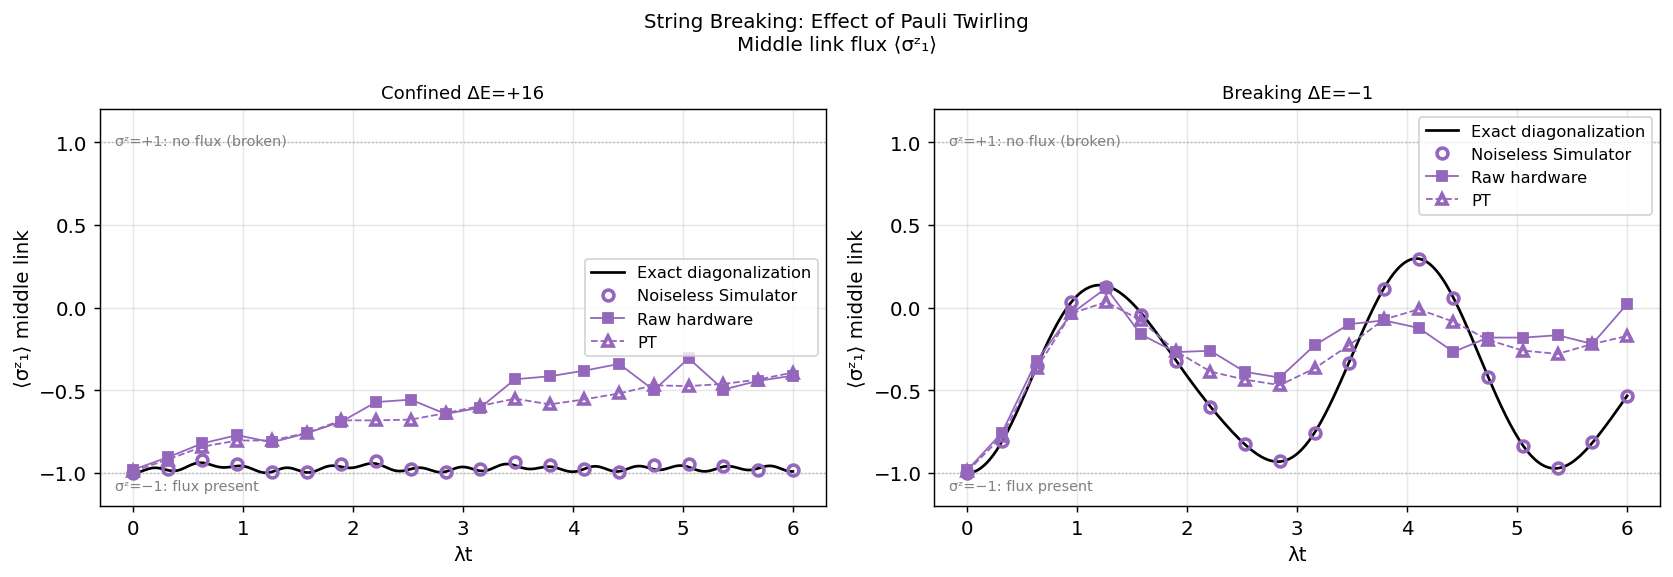

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (label, st_ex, raw_d, pt_d, m, g, lam) in zip(axes, [
    ('Confined ΔE=+16',
     st_conf, occ_raw_conf, occ_pt_conf,
     m_conf, g_conf, lam_conf),
    ('Breaking ΔE=−1',
     st_brk, occ_raw_brk, occ_pt_brk,
     m_brk, g_brk, lam_brk),
]):
    # Exact diagonalization
    ax.plot(times_exact,
            [float(np.real(s.conj()@SZ1@s)) for s in st_ex],
            'k-', lw=1.5, label='Exact diagonalization')

    # Noiseless Trotter
    sz1_nl = []
    for t in times_hw:
        if t == 0:
            sz1_nl.append(-1.0); continue
        L  = max(1, round(t/0.15))
        qc_nl = QuantumCircuit(7)
        for q in [0,1,3,5,6]: qc_nl.x(q)
        u1_half(qc_nl, m, g, t/L)
        for _ in range(L-1):
            u3(qc_nl, lam, t/L)
            u1_full(qc_nl, m, g, t/L)
        u3(qc_nl, lam, t/L)
        u1_half(qc_nl, m, g, t/L)
        sv  = Statevector.from_instruction(qc_nl)
        ps  = 'I'*(6-3) + 'Z' + 'I'*3
        sz1_nl.append(float(np.real(
            sv.expectation_value(SparsePauliOp(ps)))))

    ax.plot(times_hw, sz1_nl,
            'o', color='C4', ms=6, mew=2,
            markerfacecolor='none',
            label='Noiseless Simulator')

    # Raw hardware
    ax.plot(times_hw, raw_d['sz1'],
            color='C4', lw=1, ls='-',
            marker='s', ms=5,
            label='Raw hardware')

    # Pauli twirling
    ax.plot(times_hw, pt_d['sz1'],
            color='C4', lw=1, ls='--',
            marker='^', ms=6, mew=2,
            markerfacecolor='none',
            label='PT')

    ax.axhline(-1, color='gray', lw=0.8, ls=':', alpha=0.5)
    ax.axhline(+1, color='gray', lw=0.8, ls=':', alpha=0.5)
    ax.text(0.02, 0.04, 'σᶻ=−1: flux present',
            transform=ax.transAxes, fontsize=8, color='gray')
    ax.text(0.02, 0.91, 'σᶻ=+1: no flux (broken)',
            transform=ax.transAxes, fontsize=8, color='gray')

    ax.set_xlabel('λt')
    ax.set_ylabel('⟨σᶻ₁⟩ middle link')
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim(-1.2, 1.2)

fig.suptitle('String Breaking: Effect of Pauli Twirling\n'
             'Middle link flux ⟨σᶻ₁⟩',
             fontsize=11)
plt.tight_layout()
plt.show()



---

## Step 5: Gauss Sector Correction (GSC)

GSC is a classical post-processing technique that exploits the gauge symmetry of the model. It requires **no additional hardware run** 

**The idea:**
Every physical state must satisfy Gauss's law at every vertex. Hardware errors flip individual bits,
producing unphysical states that violate these conditions. GSC checks every measured bitstring
against the four Gauss conditions and discards any that fail keeping only physically valid measurement outcomes.

**The four conditions for our 7-qubit chain:**

- **G₀:** b(τ₀) + b(σ₀) must be even
- **G₁:** b(τ₁) + b(σ₀) + b(σ₁) must be even
- **G₂:** b(τ₂) + b(σ₁) + b(σ₂) must be even
- **G₃:** b(τ₃) + b(σ₂) must be even

A bitstring passing all four conditions is physical and contributes to the expectation values. A
bitstring failing any condition was caused by a hardware error and is discarded.


We first verify GSC on known states before applying it to the hardware results.(examples)

In [114]:
def check_gauss(bitstring):
    """
    Check if a measured bitstring satisfies Gauss's law
    at all 4 vertices of the 7-qubit chain.

    Qiskit bitstring convention: rightmost character = qubit 0.
    So for bitstring 'b6b5b4b3b2b1b0':
      b0 = τ₀, b1 = σ₀, b2 = τ₁, b3 = σ₁,
      b4 = τ₂, b5 = σ₂, b6 = τ₃

    Gauss condition at each vertex:
      sum of relevant bits must be even (field lines
      must start/end on charges never appear from nothing)

    Returns True if all 4 conditions satisfied (physical state)
    Returns False if any condition violated (hardware error)
    """
    bits = bitstring.replace(' ', '')

    # Extract bit at each qubit position (from right = qubit 0)
    b = [int(bits[-(i+1)]) for i in range(7)]
    # b[0]=τ₀, b[1]=σ₀, b[2]=τ₁, b[3]=σ₁,
    # b[4]=τ₂, b[5]=σ₂, b[6]=τ₃

    # G₀ = τᶻ₀ · σᶻ₀: τ₀ and σ₀ must agree
    g0 = (b[0] + b[1]) % 2 == 0

    # G₁ = τᶻ₁ · σᶻ₀ · σᶻ₁: τ₁ sees two links
    g1 = (b[2] + b[1] + b[3]) % 2 == 0

    # G₂ = τᶻ₂ · σᶻ₁ · σᶻ₂: τ₂ sees two links
    g2 = (b[4] + b[3] + b[5]) % 2 == 0

    # G₃ = τᶻ₃ · σᶻ₂: τ₃ and σ₂ must agree
    g3 = (b[6] + b[5]) % 2 == 0

    return g0 and g1 and g2 and g3


def apply_gsc(counts):
    """
    Apply Gauss Sector Correction to measurement counts.

    Discards all bitstrings that violate Gauss's law — these
    are unphysical states caused by hardware errors. Keeps only
    the physical bitstrings and renormalizes.

    Parameters
    ----------
    counts : dict of bitstring → count

    Returns
    -------
    filtered_counts     : dict with only physical bitstrings
    fraction_physical   : fraction of shots that were physical
    """
    filtered = {}
    total    = sum(counts.values())

    for bitstring, count in counts.items():
        if check_gauss(bitstring):
            filtered[bitstring] = count

    physical_shots     = sum(filtered.values())
    fraction_physical  = physical_shots / total if total > 0 else 0

    return filtered, fraction_physical


# ── Verify GSC on known states ──────────────────────────────────
print('Some examples for verification:')
print(f'  |1101011⟩ (long string)  physical: '
      f'{check_gauss("1101011")}  (expected True)')
print(f'  |1110111⟩ (two mesons)   physical: '
      f'{check_gauss("1110111")}  (expected True)')
print(f'  |0000000⟩ (vacuum)       physical: '
      f'{check_gauss("0000000")}  (expected True)')
print(f'  |1000000⟩ (isolated charge) physical: '
      f'{check_gauss("1000000")}  (expected False)')
print(f'  |1100011⟩ (error state)  physical: '
      f'{check_gauss("1100011")}  (expected False)')

Some examples for verification:
  |1101011⟩ (long string)  physical: True  (expected True)
  |1110111⟩ (two mesons)   physical: True  (expected True)
  |0000000⟩ (vacuum)       physical: True  (expected True)
  |1000000⟩ (isolated charge) physical: False  (expected False)
  |1100011⟩ (error state)  physical: False  (expected False)


#### Applying GSC to Hardware Results

We apply GSC to the Pauli twirling results not to the raw hardware results. The reason is
that PT + GSC are designed to work together: PT converts coherent errors to stochastic noise,
then GSC removes the unphysical outcomes that remain after PT. Applying GSC to raw hardware
would also work but the combination PT + GSC i think will gives the best recovery.

For each of the 40 PT result sets we:
1. Loop through every measured bitstring
2. Check if it satisfies all 4 Gauss conditions
3. Keep physical bitstrings, discard unphysical
4. Record the fraction of physical shots
5. Compute expectation values from remaining shots


In [118]:
gsc_conf = []
gsc_brk  = []
frac_conf = []
frac_brk  = []

for counts in pt_conf:
    filtered, frac = apply_gsc(counts)
    gsc_conf.append(filtered)
    frac_conf.append(frac)

for counts in pt_brk:
    filtered, frac = apply_gsc(counts)
    gsc_brk.append(filtered)
    frac_brk.append(frac)

print(f'Confined phase:')
print(f'  Physical fraction at t=0: {frac_conf[0]:.3f}')
print(f'  Physical fraction at t=6: {frac_conf[-1]:.3f}')
print(f'Breaking regime:')
print(f'  Physical fraction at t=0: {frac_brk[0]:.3f}')
print(f'  Physical fraction at t=6: {frac_brk[-1]:.3f}')

# ── Process GSC results ─────────────────────────────────────────
occ_gsc_conf = {
    'tau0': [counts_to_occupation(c, 0) for c in gsc_conf],
    'tau1': [counts_to_occupation(c, 2) for c in gsc_conf],
    'tau2': [counts_to_occupation(c, 4) for c in gsc_conf],
    'tau3': [counts_to_occupation(c, 6) for c in gsc_conf],
    'sz0':  [counts_to_flux(c, 1) for c in gsc_conf],
    'sz1':  [counts_to_flux(c, 3) for c in gsc_conf],
    'sz2':  [counts_to_flux(c, 5) for c in gsc_conf],
}

occ_gsc_brk = {
    'tau0': [counts_to_occupation(c, 0) for c in gsc_brk],
    'tau1': [counts_to_occupation(c, 2) for c in gsc_brk],
    'tau2': [counts_to_occupation(c, 4) for c in gsc_brk],
    'tau3': [counts_to_occupation(c, 6) for c in gsc_brk],
    'sz0':  [counts_to_flux(c, 1) for c in gsc_brk],
    'sz1':  [counts_to_flux(c, 3) for c in gsc_brk],
    'sz2':  [counts_to_flux(c, 5) for c in gsc_brk],
}

print('\nGSC results processed')
print(f'Confined τ₀ at t=0: '
      f'{occ_gsc_conf["tau0"][0]:.4f} (expected 1.0)')
print(f'Confined σ₁ at t=0: '
      f'{occ_gsc_conf["sz1"][0]:.4f}  (expected -1.0)')

Confined phase:
  Physical fraction at t=0: 0.967
  Physical fraction at t=6: 0.244
Breaking regime:
  Physical fraction at t=0: 0.965
  Physical fraction at t=6: 0.241

GSC results processed
Confined τ₀ at t=0: 1.0000 (expected 1.0)
Confined σ₁ at t=0: -1.0000  (expected -1.0)


# FINAL PLOTS: ALL 4 CURVES TOGETHER
## Exact / Noiseless / Raw / PT / PT+GSC
## Plot 1: Confined phase (all 4 matter site)

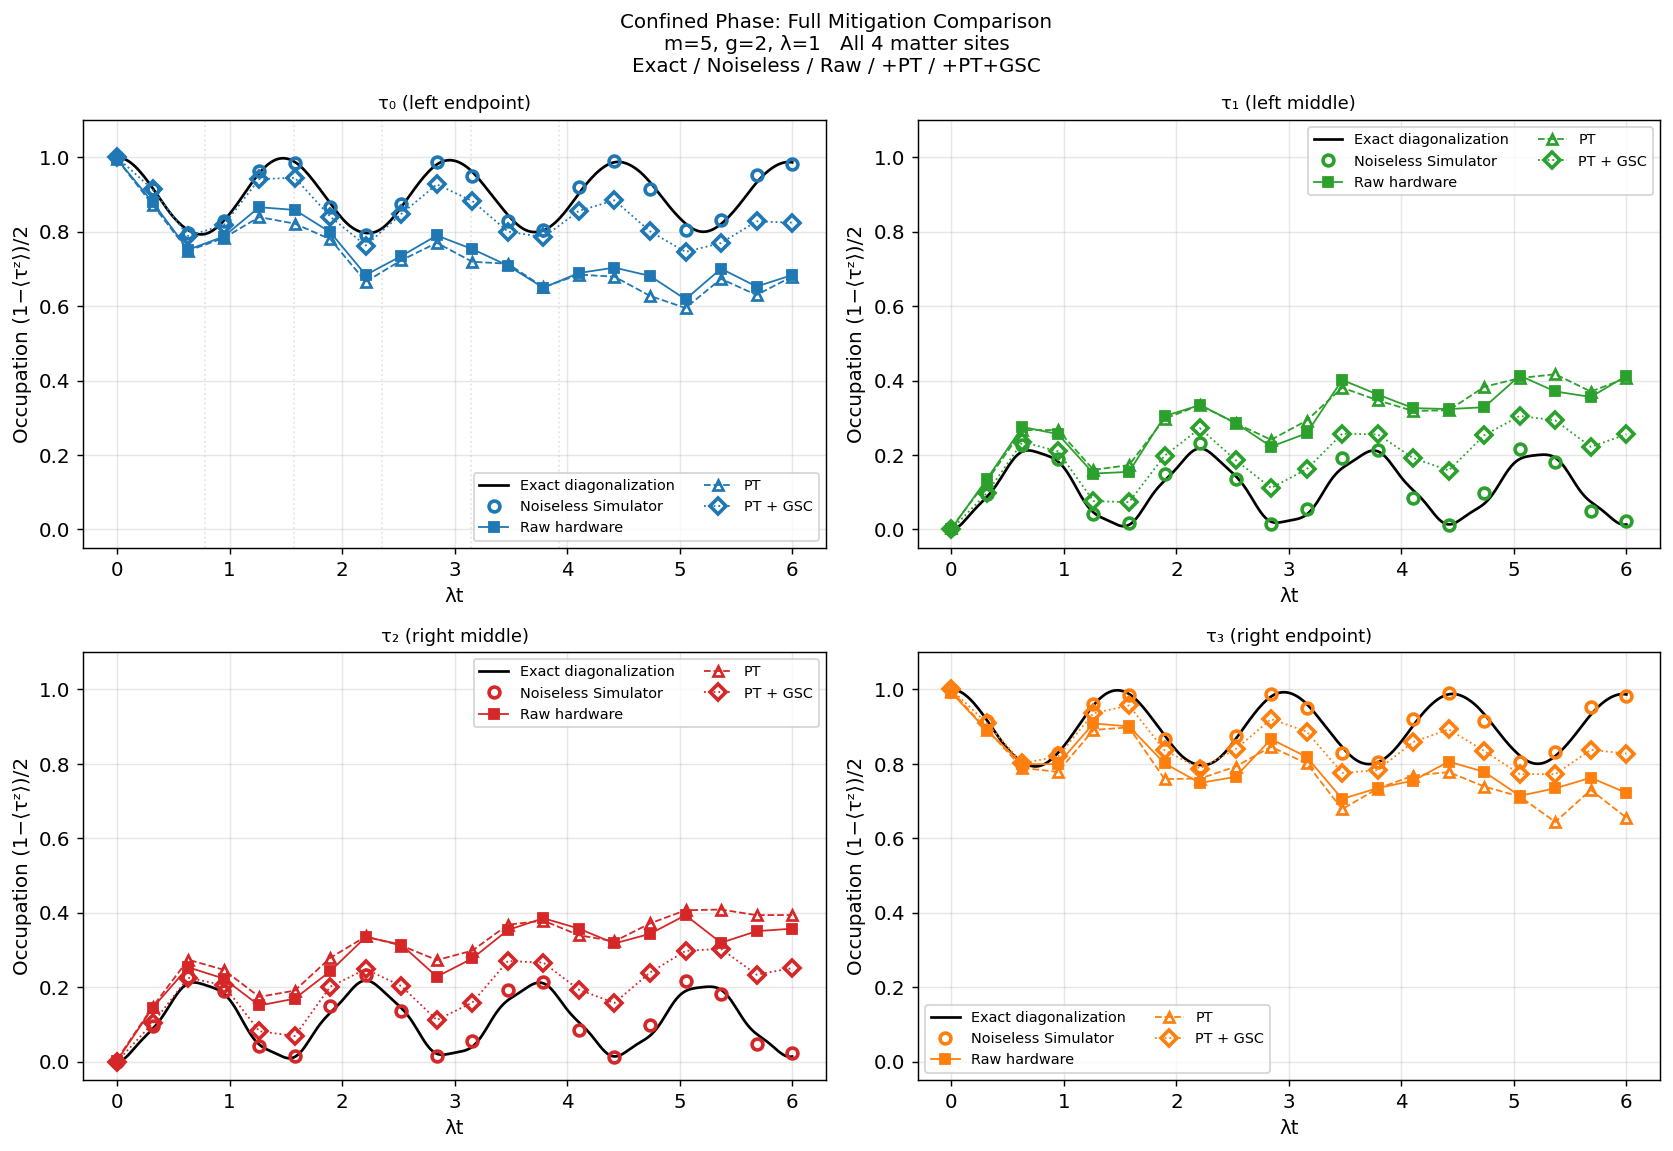

In [121]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

matter_sites = [
    (0, 'τ₀ (left endpoint)',  'C0', TZ0, 'tau0'),
    (2, 'τ₁ (left middle)',    'C2', TZ1, 'tau1'),
    (4, 'τ₂ (right middle)',   'C3', TZ2, 'tau2'),
    (6, 'τ₃ (right endpoint)', 'C1', TZ3, 'tau3'),
]

for ax, (qidx, name, col, TZ_op, key) in zip(axes, matter_sites):

    # Exact diagonalization
    ax.plot(times_exact,
            [occ(s, TZ_op) for s in st_conf],
            'k-', lw=1.5, label='Exact diagonalization')

    # Noiseless Trotter
    ax.plot(times_hw, nl_conf[key],
            'o', color=col, ms=6, mew=2,
            markerfacecolor='none',
            label='Noiseless Simulator')

    # Raw hardware
    ax.plot(times_hw, occ_raw_conf[key],
            color=col, lw=1, ls='-',
            marker='s', ms=5,
            label='Raw hardware')

    # PT
    ax.plot(times_hw, occ_pt_conf[key],
            color=col, lw=1, ls='--',
            marker='^', ms=6, mew=1.5,
            markerfacecolor='none',
            label='PT')

    # PT + GSC
    ax.plot(times_hw, occ_gsc_conf[key],
            color=col, lw=1, ls=':',
            marker='D', ms=6, mew=2,
            markerfacecolor='none',
            label='PT + GSC')

    if qidx == 0:
        Ty = 2*np.pi/(2*g_conf)
        for k in range(1, 6):
            ax.axvline(k*Ty/2, color='gray',
                       alpha=0.2, lw=1, ls=':')

    ax.set_xlabel('λt')
    ax.set_ylabel('Occupation (1−⟨τᶻ⟩)/2')
    ax.set_title(name, fontsize=10)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)
    ax.set_ylim(-0.05, 1.1)

fig.suptitle('Confined Phase: Full Mitigation Comparison\n'
             'm=5, g=2, λ=1   All 4 matter sites\n'
             'Exact / Noiseless / Raw / +PT / +PT+GSC',
             fontsize=11)
plt.tight_layout()
plt.show()


## Plot 2: String breaking (middle link flux)

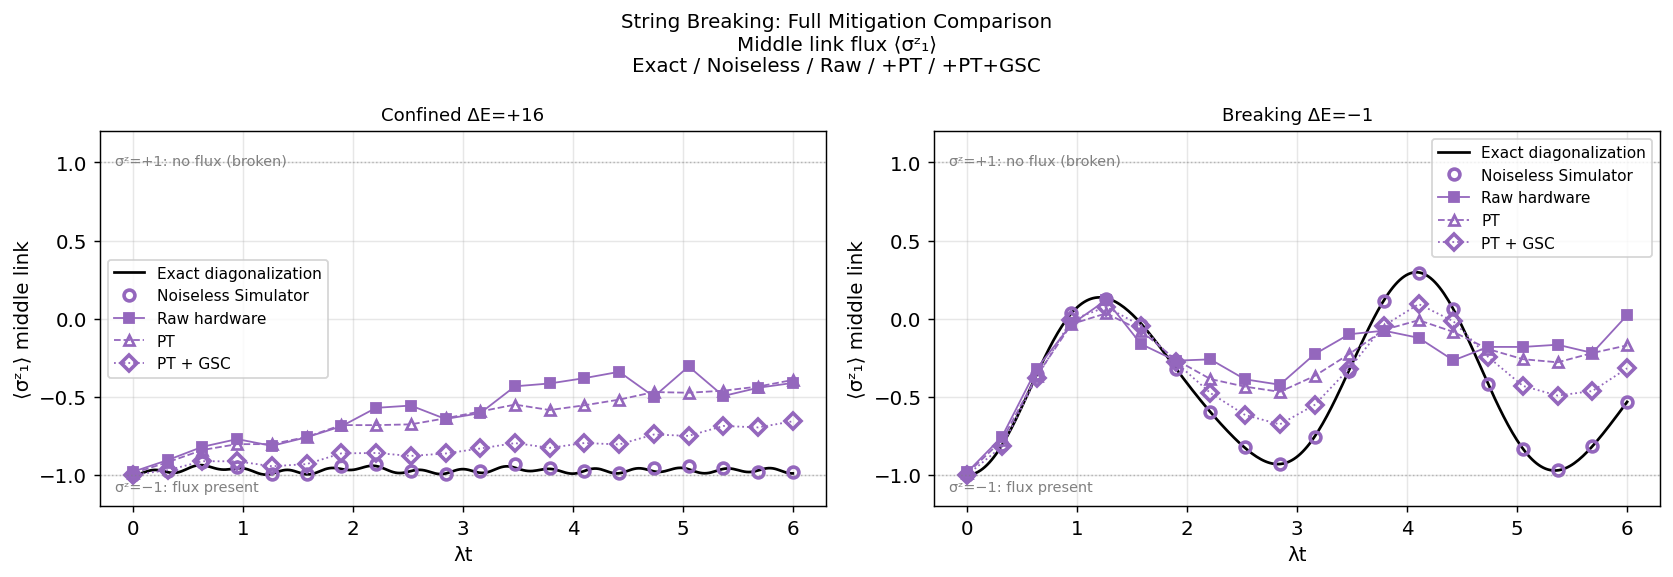


Summary — τ₀ at t=0:
  Exact:        1.0000
  Noiseless:    1.0000
  Raw hardware: 0.9952
  + PT:         0.9947
  + PT + GSC:   1.0000


In [125]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (label, st_ex, raw_d, pt_d, gsc_d, m, g, lam) in zip(
        axes, [
    ('Confined ΔE=+16',
     st_conf, occ_raw_conf, occ_pt_conf, occ_gsc_conf,
     m_conf, g_conf, lam_conf),
    ('Breaking ΔE=−1',
     st_brk, occ_raw_brk, occ_pt_brk, occ_gsc_brk,
     m_brk, g_brk, lam_brk),
]):
    # Exact diagonalization
    ax.plot(times_exact,
            [float(np.real(s.conj()@SZ1@s)) for s in st_ex],
            'k-', lw=1.5, label='Exact diagonalization')

    # Noiseless Trotter
    sz1_nl = []
    for t in times_hw:
        if t == 0:
            sz1_nl.append(-1.0); continue
        L  = max(1, round(t/0.15))
        qc_nl = QuantumCircuit(7)
        for q in [0,1,3,5,6]: qc_nl.x(q)
        u1_half(qc_nl, m, g, t/L)
        for _ in range(L-1):
            u3(qc_nl, lam, t/L)
            u1_full(qc_nl, m, g, t/L)
        u3(qc_nl, lam, t/L)
        u1_half(qc_nl, m, g, t/L)
        sv  = Statevector.from_instruction(qc_nl)
        ps  = 'I'*(6-3) + 'Z' + 'I'*3
        sz1_nl.append(float(np.real(
            sv.expectation_value(SparsePauliOp(ps)))))

    ax.plot(times_hw, sz1_nl,
            'o', color='C4', ms=6, mew=2,
            markerfacecolor='none',
            label='Noiseless Simulator')

    # Raw hardware
    ax.plot(times_hw, raw_d['sz1'],
            color='C4', lw=1, ls='-',
            marker='s', ms=5,
            label='Raw hardware')

    # PT
    ax.plot(times_hw, pt_d['sz1'],
            color='C4', lw=1, ls='--',
            marker='^', ms=6, mew=1.5,
            markerfacecolor='none',
            label='PT')

    # PT + GSC
    ax.plot(times_hw, gsc_d['sz1'],
            color='C4', lw=1, ls=':',
            marker='D', ms=6, mew=2,
            markerfacecolor='none',
            label='PT + GSC')

    ax.axhline(-1, color='gray', lw=0.8, ls=':', alpha=0.5)
    ax.axhline(+1, color='gray', lw=0.8, ls=':', alpha=0.5)
    ax.text(0.02, 0.04, 'σᶻ=−1: flux present',
            transform=ax.transAxes, fontsize=8, color='gray')
    ax.text(0.02, 0.91, 'σᶻ=+1: no flux (broken)',
            transform=ax.transAxes, fontsize=8, color='gray')

    ax.set_xlabel('λt')
    ax.set_ylabel('⟨σᶻ₁⟩ middle link')
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8.5)
    ax.grid(alpha=0.3)
    ax.set_ylim(-1.2, 1.2)

fig.suptitle('String Breaking: Full Mitigation Comparison\n'
             'Middle link flux ⟨σᶻ₁⟩\n'
             'Exact / Noiseless / Raw / +PT / +PT+GSC',
             fontsize=11)
plt.tight_layout()
plt.show()

print('\nSummary — τ₀ at t=0:')
print(f'  Exact:        1.0000')
print(f'  Noiseless:    {nl_conf["tau0"][0]:.4f}')
print(f'  Raw hardware: {occ_raw_conf["tau0"][0]:.4f}')
print(f'  + PT:         {occ_pt_conf["tau0"][0]:.4f}')
print(f'  + PT + GSC:   {occ_gsc_conf["tau0"][0]:.4f}')

# FINAL CLEAN PLOTS 
## Plot 1: Confined phase: endpoint

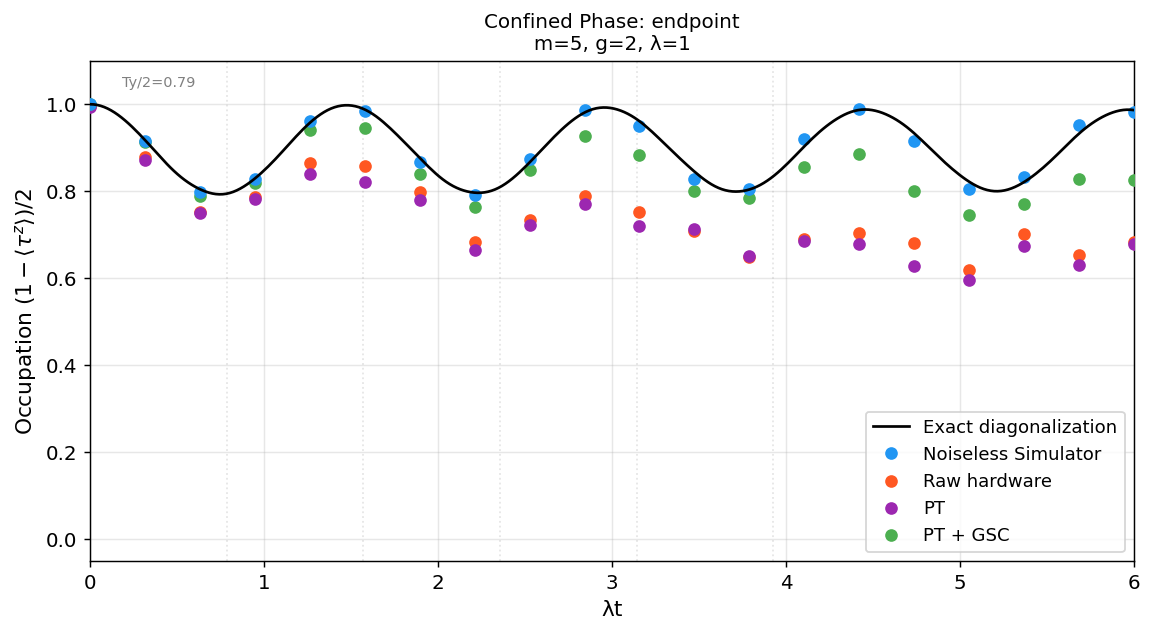

In [100]:
# Colors
c_exact     = 'black'
c_noiseless = '#2196F3'   # blue
c_raw       = '#FF5722'   # orange-red
c_pt        = '#9C27B0'   # purple
c_gsc       = '#4CAF50'   # green

# ── Plot 1: Confined phase — τ₀ occupation ─────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

# Exact diagonalization — black solid line
ax.plot(times_exact,
        [occ(s, TZ0) for s in st_conf],
        color=c_exact, lw=1.5, ls='-',
        label='Exact diagonalization', zorder=5)

# Noiseless Trotter — blue circles
ax.plot(times_hw, nl_conf['tau0'],
        'o', color=c_noiseless, ms=7, mew=0,
        label='Noiseless Simulator', zorder=4)

# Raw hardware — red circles
ax.plot(times_hw, occ_raw_conf['tau0'],
        'o', color=c_raw, ms=7, mew=0,
        label='Raw hardware', zorder=3)

# PT — purple circles
ax.plot(times_hw, occ_pt_conf['tau0'],
        'o', color=c_pt, ms=7, mew=0,
        label='PT', zorder=3)

# PT + GSC — green circles
ax.plot(times_hw, occ_gsc_conf['tau0'],
        'o', color=c_gsc, ms=7, mew=0,
        label='PT + GSC', zorder=3)

# Yo-yo period markers
Ty = 2*np.pi/(2*g_conf)
for k in range(1, 6):
    ax.axvline(k*Ty/2, color='gray',
               alpha=0.2, lw=1, ls=':')
ax.text(Ty/4, 1.04, f'Ty/2={Ty/2:.2f}',
        fontsize=8, ha='center', color='gray')

ax.set_xlabel('λt', fontsize=12)
ax.set_ylabel('Occupation $(1-\\langle\\tau^z\\rangle)/2$',
              fontsize=12)
ax.set_title('Confined Phase: endpoint\n'
             'm=5, g=2, λ=1', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_ylim(-0.05, 1.1)
ax.set_xlim(0, 6)
plt.tight_layout()
plt.show()


## Plot 2: String breaking(middle link flux)

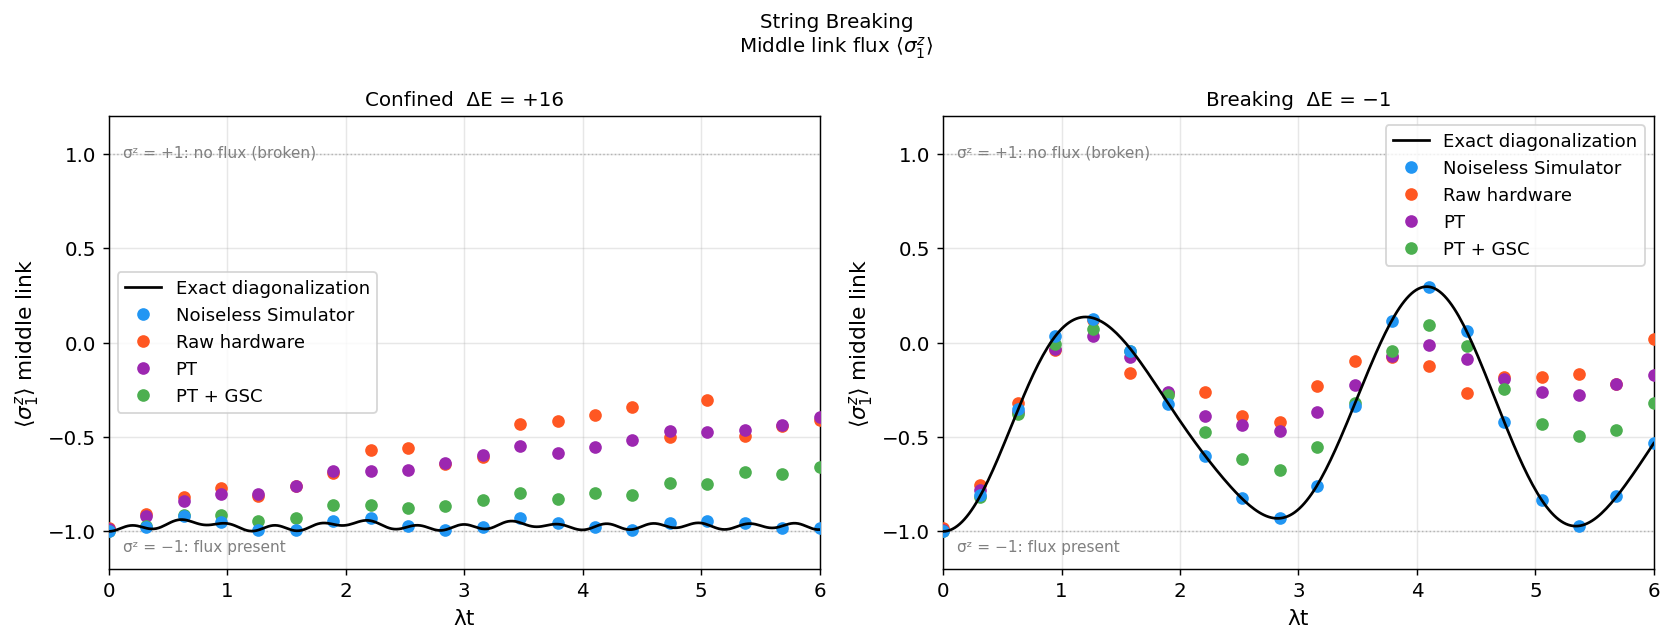

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (label, st_ex, raw_d, pt_d, gsc_d,
         m, g, lam) in zip(axes, [

    ('Confined  ΔE = +16',
     st_conf, occ_raw_conf, occ_pt_conf, occ_gsc_conf,
     m_conf, g_conf, lam_conf),

    ('Breaking  ΔE = −1',
     st_brk, occ_raw_brk, occ_pt_brk, occ_gsc_brk,
     m_brk, g_brk, lam_brk),
]):
    # Exact diagonalization
    ax.plot(times_exact,
            [float(np.real(s.conj()@SZ1@s)) for s in st_ex],
            color=c_exact, lw=1.5, ls='-',
            label='Exact diagonalization', zorder=5)

    # Noiseless Trotter
    sz1_nl = []
    for t in times_hw:
        if t == 0:
            sz1_nl.append(-1.0); continue
        L  = max(1, round(t/0.15))
        qc_nl = QuantumCircuit(7)
        for q in [0,1,3,5,6]: qc_nl.x(q)
        u1_half(qc_nl, m, g, t/L)
        for _ in range(L-1):
            u3(qc_nl, lam, t/L)
            u1_full(qc_nl, m, g, t/L)
        u3(qc_nl, lam, t/L)
        u1_half(qc_nl, m, g, t/L)
        sv  = Statevector.from_instruction(qc_nl)
        ps  = 'I'*(6-3) + 'Z' + 'I'*3
        sz1_nl.append(float(np.real(
            sv.expectation_value(SparsePauliOp(ps)))))

    ax.plot(times_hw, sz1_nl,
            'o', color=c_noiseless, ms=7, mew=0,
            label='Noiseless Simulator', zorder=4)

    # Raw hardware
    ax.plot(times_hw, raw_d['sz1'],
            'o', color=c_raw, ms=7, mew=0,
            label='Raw hardware', zorder=3)

    # PT
    ax.plot(times_hw, pt_d['sz1'],
            'o', color=c_pt, ms=7, mew=0,
            label='PT', zorder=3)

    # PT + GSC
    ax.plot(times_hw, gsc_d['sz1'],
            'o', color=c_gsc, ms=7, mew=0,
            label='PT + GSC', zorder=3)

    ax.axhline(-1, color='gray', lw=0.8, ls=':', alpha=0.5)
    ax.axhline(+1, color='gray', lw=0.8, ls=':', alpha=0.5)
    ax.text(0.02, 0.04, 'σᶻ = −1: flux present',
            transform=ax.transAxes,
            fontsize=8.5, color='gray')
    ax.text(0.02, 0.91, 'σᶻ = +1: no flux (broken)',
            transform=ax.transAxes,
            fontsize=8.5, color='gray')

    ax.set_xlabel('λt', fontsize=12)
    ax.set_ylabel('$\\langle\\sigma^z_1\\rangle$ middle link',
                  fontsize=12)
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_ylim(-1.2, 1.2)
    ax.set_xlim(0, 6)

fig.suptitle('String Breaking\n'
             'Middle link flux $\\langle\\sigma^z_1\\rangle$',
             fontsize=11)
plt.tight_layout()
plt.show()
